# Imports & Metrics

In [1]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import nibabel as nib
from tqdm import tqdm
from scipy.stats import wilcoxon
from nnunetv2.inference.predict_from_raw_data import nnUNetPredictor

# ==========================================
# 1. CONFIGURATION
# ==========================================
# Path to your BEST checkpoint found earlier
CHECKPOINT_PATH = "checkpoints_attention_unet/epoch_96.pth" 

# Path to the dataset
DATASET_ROOT = r"D:/Capstone/Experiment 4/Datasets/ISLES-2022"

# Path to nnU-Net Results (Experiment 3)
NNUNET_RESULTS_DIR = r"D:/Capstone/Experiment 3/nnUNet_2_channel/nnUNet_results/Dataset124_ISLES22_2CH/nnUNetTrainer__nnUNetPlans__2d"

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Configuration Set. Using Device: {DEVICE}")

# ==========================================
# 2. MODEL ARCHITECTURE (Required to Load Weights)
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Conv2d(F_g, F_int, 1)
        self.W_x = nn.Conv2d(F_l, F_int, 1)
        self.psi = nn.Conv2d(F_int, 1, 1)
    def forward(self, g, x):
        psi = F.relu(self.W_g(g) + self.W_x(x))
        psi = torch.sigmoid(self.psi(psi))
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(2, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.enc4 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.dec3 = DoubleConv(256 + 128, 128)
        self.dec2 = DoubleConv(128 + 64, 64)
        self.dec1 = DoubleConv(64 + 32, 32)
        self.att3 = AttentionGate(256, 128, 64)
        self.att2 = AttentionGate(128, 64, 32)
        self.att1 = AttentionGate(64, 32, 16)
        self.out = nn.Conv2d(32, 2, 1)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        d3 = F.interpolate(e4, scale_factor=2, mode="bilinear", align_corners=False)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], 1))
        d2 = F.interpolate(d3, scale_factor=2, mode="bilinear", align_corners=False)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], 1))
        d1 = F.interpolate(d2, scale_factor=2, mode="bilinear", align_corners=False)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], 1))
        return self.out(d1)

# ==========================================
# 3. HELPER FUNCTIONS & METRICS
# ==========================================
def norm_slice(img):
    """Normalize a single 2D slice."""
    return (img - np.mean(img)) / (np.std(img) + 1e-8)

def compute_metrics_slice(pred, gt):
    """
    Calculates 5 key metrics for a single slice:
    Dice, F1, Recall, Precision, Accuracy.
    """
    pred = pred.flatten()
    gt = gt.flatten()
    
    TP = (pred * gt).sum()
    FP = (pred * (1 - gt)).sum()
    FN = ((1 - pred) * gt).sum()
    TN = ((1 - pred) * (1 - gt)).sum()
    
    # Handle Edge Case: Empty Prediction & Empty GT = Perfect Match
    if gt.sum() == 0 and pred.sum() == 0:
        return 1.0, 1.0, 1.0, 1.0, 1.0

    # 1. Dice Score
    dice = (2. * TP) / (2. * TP + FP + FN + 1e-6)
    
    # 2. F1 Score (Mathematically same as Dice for binary)
    f1 = dice 
    
    # 3. Recall (Sensitivity)
    recall = TP / (TP + FN + 1e-6)
    
    # 4. Precision
    precision = TP / (TP + FP + 1e-6)
    
    # 5. Accuracy
    accuracy = (TP + TN) / (TP + TN + FP + FN + 1e-6)
    
    return dice, f1, recall, precision, accuracy

# ==========================================
# 4. LOAD BOTH MODELS
# ==========================================
# --- A. Load Attention U-Net ---
attn_model = AttentionUNet().to(DEVICE)
if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading Attention U-Net from: {CHECKPOINT_PATH}")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    # Handle 'model_state' wrapper if present
    state_dict = ckpt['model_state'] if 'model_state' in ckpt else ckpt
    attn_model.load_state_dict({k.replace("module.", ""): v for k, v in state_dict.items()})
    attn_model.eval()
else:
    raise FileNotFoundError(f"❌ Checkpoint not found: {CHECKPOINT_PATH}")

# --- B. Initialize nnU-Net ---
print("Initializing nnU-Net Predictor...")
predictor = nnUNetPredictor(
    tile_step_size=0.5,
    use_gaussian=True,
    use_mirroring=False,
    device=DEVICE,
    verbose=False
)
predictor.initialize_from_trained_model_folder(
    NNUNET_RESULTS_DIR, 
    use_folds=(0,), 
    checkpoint_name='checkpoint_best.pth'
)
print("✅ Both Models Loaded Successfully.")

# ==========================================
# 5. MAIN COMPARISON LOOP
# ==========================================
images_dir = os.path.join(DATASET_ROOT, "imagesTr")
labels_dir = os.path.join(DATASET_ROOT, "labelsTr")

# Find all cases
case_files = glob.glob(os.path.join(images_dir, "*_0000.nii.gz"))
results_list = []

print(f"\nStarting Evaluation on {len(case_files)} cases...")

with torch.no_grad():
    for case_path in tqdm(case_files, desc="Processing Patients"):
        # Identify file paths
        case_id = os.path.basename(case_path).replace("_0000.nii.gz", "")
        adc_path = case_path.replace("_0000.nii.gz", "_0001.nii.gz")
        label_path = os.path.join(labels_dir, f"{case_id}.nii.gz")
        
        if not os.path.exists(adc_path) or not os.path.exists(label_path):
            continue

        # --- LOAD FULL VOLUME ---
        dwi_vol = nib.load(case_path).get_fdata()
        adc_vol = nib.load(adc_path).get_fdata()
        gt_vol  = nib.load(label_path).get_fdata()
        
        # --- NNUNET INFERENCE (FULL VOLUME) ---
        # nnU-Net needs the full volume context to normalize correctly
        img_obj = nib.load(case_path)
        props = {'spacing': img_obj.header.get_zooms()[:3], 'shape_before_cropping': dwi_vol.shape}
        nn_input = np.stack([dwi_vol, adc_vol], axis=0)
        
        # Predict
        nn_output = predictor.predict_single_npy_array(nn_input, image_properties=props, save_or_return_probabilities=True)
        nn_prob_vol = nn_output[1] # Class 1 probability map

        # --- SLICE-BY-SLICE EVALUATION ---
        depth = dwi_vol.shape[2]
        
        for z in range(depth):
            # 1. Extract Slices
            dwi_slice = dwi_vol[:, :, z]
            adc_slice = adc_vol[:, :, z]
            gt_slice  = gt_vol[:, :, z]
            
            # (Optional) Skip completely empty slices to speed up? 
            # Currently checking ALL slices for accurate accuracy/precision stats.

            # 2. Attention U-Net Prediction
            dwi_n = norm_slice(dwi_slice)
            adc_n = norm_slice(adc_slice)
            inp_tensor = torch.tensor(np.stack([dwi_n, adc_n]), dtype=torch.float32).unsqueeze(0).to(DEVICE)
            
            # Resize to 256x256 (Model Input Size)
            inp_resized = F.interpolate(inp_tensor, size=(256, 256), mode='bilinear', align_corners=False)
            
            logits = attn_model(inp_resized)
            # ARGMAX because model output is (Batch, 2, H, W)
            att_pred = torch.argmax(logits, dim=1).squeeze().cpu().numpy()

            # 3. nnU-Net Prediction (Resize specific slice to 256)
            nn_slice_prob = nn_prob_vol[:, :, z]
            nn_tensor = torch.tensor(nn_slice_prob).unsqueeze(0).unsqueeze(0)
            nn_resized = F.interpolate(nn_tensor, size=(256, 256), mode='bilinear', align_corners=False).squeeze().cpu().numpy()
            nn_pred = (nn_resized > 0.5).astype(np.float32)

            # 4. Ground Truth (Resize to 256)
            gt_tensor = torch.tensor(gt_slice).unsqueeze(0).unsqueeze(0)
            gt_resized = F.interpolate(gt_tensor, size=(256, 256), mode='nearest').squeeze().cpu().numpy()

            # 5. Compute Metrics for both
            m_att = compute_metrics_slice(att_pred, gt_resized)
            m_nnu = compute_metrics_slice(nn_pred, gt_resized)
            
            # Store
            results_list.append({
                "Case": case_id, "Slice": z,
                "Dice_Attn": m_att[0], "F1_Attn": m_att[1], "Rec_Attn": m_att[2], "Prec_Attn": m_att[3], "Acc_Attn": m_att[4],
                "Dice_nnU":  m_nnu[0], "F1_nnU":  m_nnu[1], "Rec_nnU":  m_nnu[2], "Prec_nnU":  m_nnu[3], "Acc_nnU":  m_nnu[4]
            })

# ==========================================
# 6. SAVE & GENERATE P-VALUE TABLE
# ==========================================
# Create DataFrame
df = pd.DataFrame(results_list)

# Save RAW metrics for every single slice
csv_filename = "comparison_full_metrics.csv"
df.to_csv(csv_filename, index=False)
print(f"\n✅ Raw metrics saved to '{csv_filename}'")

# Generate Supervisor's Summary Table
metrics_list = ["Dice", "F1", "Rec", "Prec", "Acc"]
summary_data = []

print("\n" + "="*95)
print(f"{'Metric':<10} | {'Attn U-Net (Mean)':<20} | {'nnU-Net (Mean)':<20} | {'P-Value':<10} | {'Significant?'}")
print("="*95)

for m in metrics_list:
    col_att = f"{m}_Attn"
    col_nnu = f"{m}_nnU"
    
    # Calculate Means
    mean_att = df[col_att].mean()
    mean_nnu = df[col_nnu].mean()
    
    # Statistical Test (Wilcoxon Signed-Rank Test)
    # We compare the two lists of scores to see if the difference is significant
    stat, p_val = wilcoxon(df[col_att], df[col_nnu])
    
    is_significant = "Yes" if p_val < 0.05 else "No"
    
    summary_data.append({
        "Metric": m,
        "Attn_Mean": mean_att,
        "nnU_Mean": mean_nnu,
        "P_Value": p_val,
        "Significant": is_significant
    })
    
    print(f"{m:<10} | {mean_att:.4f}             | {mean_nnu:.4f}             | {p_val:.2e}   | {is_significant}")

# Save Summary Table
summary_csv = "p_value_table.csv"
pd.DataFrame(summary_data).to_csv(summary_csv, index=False)
print("\n" + "="*95)
print(f"✅ Summary table saved to '{summary_csv}'")
print("Done.")

Using device: cuda


✅ Device: cuda


C:\Users\ankit\AppData\Local\Temp\ipykernel_18268\3955787985.py:88: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


Loading weights from checkpoints_attention_unet/epoch_96.pth...

Processing 250 cases for Confusion Matrix...


100%|██████████| 250/250 [03:28<00:00,  1.20it/s]


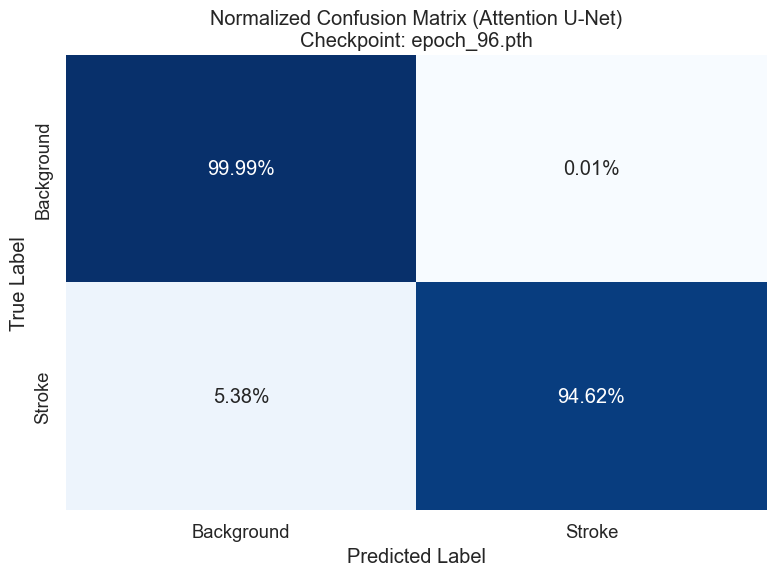


CONFUSION MATRIX STATS
True Negatives  (TN): 1,024,421,250
False Positives (FP): 92,838
False Negatives (FN): 180,283
True Positives  (TP): 3,172,253
----------------------------------------
✅ Confusion Matrix saved as: confusion_matrix.png


In [1]:
import os
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import nibabel as nib
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================
# 1. CONFIGURATION
# ==========================================
CHECKPOINT_PATH = "checkpoints_attention_unet/epoch_96.pth"
DATASET_ROOT = r"D:/Capstone/Experiment 4/Datasets/ISLES-2022"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Device: {DEVICE}")

# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Conv2d(F_g, F_int, 1)
        self.W_x = nn.Conv2d(F_l, F_int, 1)
        self.psi = nn.Conv2d(F_int, 1, 1)
    def forward(self, g, x):
        psi = F.relu(self.W_g(g) + self.W_x(x))
        psi = torch.sigmoid(self.psi(psi))
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(2, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.enc4 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.dec3 = DoubleConv(256 + 128, 128)
        self.dec2 = DoubleConv(128 + 64, 64)
        self.dec1 = DoubleConv(64 + 32, 32)
        self.att3 = AttentionGate(256, 128, 64)
        self.att2 = AttentionGate(128, 64, 32)
        self.att1 = AttentionGate(64, 32, 16)
        self.out = nn.Conv2d(32, 2, 1)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        d3 = F.interpolate(e4, scale_factor=2, mode="bilinear", align_corners=False)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], 1))
        d2 = F.interpolate(d3, scale_factor=2, mode="bilinear", align_corners=False)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], 1))
        d1 = F.interpolate(d2, scale_factor=2, mode="bilinear", align_corners=False)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], 1))
        return self.out(d1)

# ==========================================
# 3. HELPER FUNCTION
# ==========================================
def norm_slice(img):
    return (img - np.mean(img)) / (np.std(img) + 1e-8)

# ==========================================
# 4. LOAD MODEL
# ==========================================
model = AttentionUNet().to(DEVICE)
if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading weights from {CHECKPOINT_PATH}...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    state_dict = ckpt['model_state'] if 'model_state' in ckpt else ckpt
    model.load_state_dict({k.replace("module.", ""): v for k, v in state_dict.items()})
    model.eval()
else:
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

# ==========================================
# 5. GENERATE CONFUSION MATRIX
# ==========================================
images_dir = os.path.join(DATASET_ROOT, "imagesTr")
labels_dir = os.path.join(DATASET_ROOT, "labelsTr")
case_files = glob.glob(os.path.join(images_dir, "*_0000.nii.gz"))

# Initialize Counters (Using float to prevent overflow)
TP = 0.0  # True Positive (Stroke correctly identified)
TN = 0.0  # True Negative (Background correctly identified)
FP = 0.0  # False Positive (Background mistaken for Stroke)
FN = 0.0  # False Negative (Stroke missed)

print(f"\nProcessing {len(case_files)} cases for Confusion Matrix...")

with torch.no_grad():
    for case_path in tqdm(case_files):
        # Paths
        case_id = os.path.basename(case_path).replace("_0000.nii.gz", "")
        adc_path = case_path.replace("_0000.nii.gz", "_0001.nii.gz")
        label_path = os.path.join(labels_dir, f"{case_id}.nii.gz")
        
        if not os.path.exists(adc_path) or not os.path.exists(label_path):
            continue

        # Load Data
        dwi_vol = nib.load(case_path).get_fdata()
        adc_vol = nib.load(adc_path).get_fdata()
        gt_vol  = nib.load(label_path).get_fdata()
        
        # Handle 4D if present
        if dwi_vol.ndim == 4: dwi_vol = dwi_vol[..., 0]
        if adc_vol.ndim == 4: adc_vol = adc_vol[..., 0]
        if gt_vol.ndim == 4:  gt_vol  = gt_vol[..., 0]

        depth = dwi_vol.shape[2]

        for z in range(depth):
            dwi_slice = dwi_vol[:, :, z]
            adc_slice = adc_vol[:, :, z]
            gt_slice  = gt_vol[:, :, z]

            # Normalize & Tensorize
            dwi_n = norm_slice(dwi_slice)
            adc_n = norm_slice(adc_slice)
            
            inp = torch.tensor(np.stack([dwi_n, adc_n]), dtype=torch.float32).unsqueeze(0).to(DEVICE)
            
            # Resize Input to 256x256
            inp_res = F.interpolate(inp, size=(256, 256), mode='bilinear', align_corners=False)
            
            # Predict
            logits = model(inp_res)
            preds = torch.argmax(logits, dim=1).squeeze().cpu().numpy() # 0 or 1
            
            # Resize Ground Truth to match prediction (256x256)
            gt_tensor = torch.tensor(gt_slice).unsqueeze(0).unsqueeze(0)
            gt_res = F.interpolate(gt_tensor, size=(256, 256), mode='nearest').squeeze().numpy()

            # Flatten
            pred_flat = preds.flatten()
            gt_flat   = gt_res.flatten()

            # Calculate Confusion Matrix Components
            # 1 = Stroke, 0 = Background
            TP += ((pred_flat == 1) & (gt_flat == 1)).sum()
            TN += ((pred_flat == 0) & (gt_flat == 0)).sum()
            FP += ((pred_flat == 1) & (gt_flat == 0)).sum()
            FN += ((pred_flat == 0) & (gt_flat == 1)).sum()

# ==========================================
# 6. PLOT CONFUSION MATRIX
# ==========================================
# Construct Matrix
cm = np.array([[TN, FP], [FN, TP]])
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] # Normalize by row (True labels)

# Labels
labels = ['Background', 'Stroke']

plt.figure(figsize=(8, 6))
sns.set(font_scale=1.2)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', 
            xticklabels=labels, yticklabels=labels, cbar=False)

plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title(f'Normalized Confusion Matrix (Attention U-Net)\nCheckpoint: epoch_96.pth')
plt.tight_layout()

save_path = "confusion_matrix.png"
plt.savefig(save_path, dpi=300)
plt.show()

print("\n" + "="*40)
print("CONFUSION MATRIX STATS")
print("="*40)
print(f"True Negatives  (TN): {int(TN):,}")
print(f"False Positives (FP): {int(FP):,}")
print(f"False Negatives (FN): {int(FN):,}")
print(f"True Positives  (TP): {int(TP):,}")
print("-" * 40)
print(f"✅ Confusion Matrix saved as: {save_path}")

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import nibabel as nib
from tqdm import tqdm

# ==========================================
# 1. CONFIGURATION
# ==========================================
CHECKPOINT_PATH = "checkpoints_attention_unet/epoch_96.pth"
DATASET_ROOT = r"D:/Capstone/Experiment 4/Datasets/ISLES-2022"
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"✅ Device: {DEVICE}")

# ==========================================
# 2. MODEL ARCHITECTURE
# ==========================================
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1), nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1), nn.InstanceNorm2d(out_ch), nn.ReLU(inplace=True)
        )
    def forward(self, x): return self.conv(x)

class AttentionGate(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super().__init__()
        self.W_g = nn.Conv2d(F_g, F_int, 1)
        self.W_x = nn.Conv2d(F_l, F_int, 1)
        self.psi = nn.Conv2d(F_int, 1, 1)
    def forward(self, g, x):
        psi = F.relu(self.W_g(g) + self.W_x(x))
        psi = torch.sigmoid(self.psi(psi))
        return x * psi

class AttentionUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc1 = DoubleConv(2, 32)
        self.enc2 = DoubleConv(32, 64)
        self.enc3 = DoubleConv(64, 128)
        self.enc4 = DoubleConv(128, 256)
        self.pool = nn.MaxPool2d(2)
        self.dec3 = DoubleConv(256 + 128, 128)
        self.dec2 = DoubleConv(128 + 64, 64)
        self.dec1 = DoubleConv(64 + 32, 32)
        self.att3 = AttentionGate(256, 128, 64)
        self.att2 = AttentionGate(128, 64, 32)
        self.att1 = AttentionGate(64, 32, 16)
        self.out = nn.Conv2d(32, 2, 1)
    
    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        d3 = F.interpolate(e4, scale_factor=2, mode="bilinear", align_corners=False)
        e3 = self.att3(d3, e3)
        d3 = self.dec3(torch.cat([d3, e3], 1))
        d2 = F.interpolate(d3, scale_factor=2, mode="bilinear", align_corners=False)
        e2 = self.att2(d2, e2)
        d2 = self.dec2(torch.cat([d2, e2], 1))
        d1 = F.interpolate(d2, scale_factor=2, mode="bilinear", align_corners=False)
        e1 = self.att1(d1, e1)
        d1 = self.dec1(torch.cat([d1, e1], 1))
        return self.out(d1)

# ==========================================
# 3. HELPER FUNCTION
# ==========================================
def norm_slice(img):
    return (img - np.mean(img)) / (np.std(img) + 1e-8)

# ==========================================
# 4. LOAD MODEL
# ==========================================
model = AttentionUNet().to(DEVICE)
if os.path.exists(CHECKPOINT_PATH):
    print(f"Loading weights from {CHECKPOINT_PATH}...")
    ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    state_dict = ckpt['model_state'] if 'model_state' in ckpt else ckpt
    model.load_state_dict({k.replace("module.", ""): v for k, v in state_dict.items()})
    model.eval()
else:
    raise FileNotFoundError(f"Checkpoint not found: {CHECKPOINT_PATH}")

# ==========================================
# 5. CALCULATE METRICS
# ==========================================
images_dir = os.path.join(DATASET_ROOT, "imagesTr")
labels_dir = os.path.join(DATASET_ROOT, "labelsTr")
case_files = glob.glob(os.path.join(images_dir, "*_0000.nii.gz"))

TP, TN, FP, FN = 0.0, 0.0, 0.0, 0.0

print(f"\nScanning {len(case_files)} cases for Detailed Tabulation...")

with torch.no_grad():
    for case_path in tqdm(case_files):
        # Paths
        case_id = os.path.basename(case_path).replace("_0000.nii.gz", "")
        adc_path = case_path.replace("_0000.nii.gz", "_0001.nii.gz")
        label_path = os.path.join(labels_dir, f"{case_id}.nii.gz")
        
        if not os.path.exists(adc_path) or not os.path.exists(label_path):
            continue

        # Load
        dwi_vol = nib.load(case_path).get_fdata()
        adc_vol = nib.load(adc_path).get_fdata()
        gt_vol  = nib.load(label_path).get_fdata()
        
        # 4D Fix
        if dwi_vol.ndim == 4: dwi_vol = dwi_vol[..., 0]
        if adc_vol.ndim == 4: adc_vol = adc_vol[..., 0]
        if gt_vol.ndim == 4:  gt_vol  = gt_vol[..., 0]

        depth = dwi_vol.shape[2]

        for z in range(depth):
            dwi_slice = dwi_vol[:, :, z]
            adc_slice = adc_vol[:, :, z]
            gt_slice  = gt_vol[:, :, z]

            # Preprocessing
            dwi_n = norm_slice(dwi_slice)
            adc_n = norm_slice(adc_slice)
            inp = torch.tensor(np.stack([dwi_n, adc_n]), dtype=torch.float32).unsqueeze(0).to(DEVICE)
            inp_res = F.interpolate(inp, size=(256, 256), mode='bilinear', align_corners=False)
            
            # Predict
            logits = model(inp_res)
            preds = torch.argmax(logits, dim=1).squeeze().cpu().numpy()
            
            # GT Resize
            gt_tensor = torch.tensor(gt_slice).unsqueeze(0).unsqueeze(0)
            gt_res = F.interpolate(gt_tensor, size=(256, 256), mode='nearest').squeeze().numpy()

            # Accumulate Stats
            p, g = preds.flatten(), gt_res.flatten()
            TP += ((p == 1) & (g == 1)).sum()
            TN += ((p == 0) & (g == 0)).sum()
            FP += ((p == 1) & (g == 0)).sum()
            FN += ((p == 0) & (g == 1)).sum()

# ==========================================
# 6. GENERATE TABLE
# ==========================================
# Avoid division by zero
epsilon = 1e-7

sensitivity = TP / (TP + FN + epsilon)  # Recall
specificity = TN / (TN + FP + epsilon)  # True Negative Rate
precision   = TP / (TP + FP + epsilon)  # PPV
accuracy    = (TP + TN) / (TP + TN + FP + FN + epsilon)
dice_score  = (2 * TP) / (2 * TP + FP + FN + epsilon)
iou_score   = TP / (TP + FP + FN + epsilon) # Jaccard Index

# Create DataFrame
metrics_data = {
    "Metric": [
        "Sensitivity (Recall)", 
        "Specificity", 
        "Precision (PPV)", 
        "Accuracy", 
        "Dice Score (F1)", 
        "IoU (Jaccard)"
    ],
    "Value": [
        sensitivity, 
        specificity, 
        precision, 
        accuracy, 
        dice_score, 
        iou_score
    ]
}

df_table = pd.DataFrame(metrics_data)
df_table["Value"] = df_table["Value"].apply(lambda x: round(x, 4)) # Round to 4 decimals

print("\n" + "="*40)
print("FINAL PERFORMANCE TABULATION")
print("="*40)
print(df_table.to_string(index=False))
print("-" * 40)

# Save
df_table.to_csv("final_performance_table.csv", index=False)
print("✅ Table saved as: 'final_performance_table.csv'")

C:\Users\ankit\AppData\Local\Temp\ipykernel_18268\2145479508.py:87: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CHECKPOINT_PATH, map_location=DEVICE)


✅ Device: cuda
Loading weights from checkpoints_attention_unet/epoch_96.pth...

Scanning 250 cases for Detailed Tabulation...


100%|██████████| 250/250 [03:12<00:00,  1.30it/s]


FINAL PERFORMANCE TABULATION
              Metric  Value
Sensitivity (Recall) 0.9462
         Specificity 0.9999
     Precision (PPV) 0.9716
            Accuracy 0.9997
     Dice Score (F1) 0.9587
       IoU (Jaccard) 0.9207
----------------------------------------
✅ Table saved as: 'final_performance_table.csv'
